In [2]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time

# %matplotlib widget
# plt.close('all')

### Caricamento dati da file
Creazione di due file separati per aria e acqua, e riscalamento dei tempi (avevamo 12 valori per ogni anno)

In [3]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


### Definizione dei modelli da testare

In [4]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

### Definizione di prior e likelihood per i vari modelli

In [5]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

### Simulazione per i vari modelli

In [6]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7250..-81416.7250]*| it/evals=4480/5037 eff=96.6142% N=400 0   0 
[ultranest] Likelihood function evaluations: 5052
[ultranest]   logZ = -8.142e+04 +- 0.08487
[ultranest] Effective samples strategy satisfied (ESS = 1213.6, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.09, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.08 tail:0.03 total:0.09 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81424.610 +- 0.165
  single instance: logZ = -81424.610 +- 0.136
  bootstrapped   : logZ = -81424.622 +- 0.162
  tail           : logZ = +- 0.034
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.34485│ ▁ ▁▁▁▁▁▁▁▁▂▂▂▄▅▆▇▇▇▇▇▇▆▆▄▃▃▂▁▁▁▁▁▁▁ ▁ │0.35316    0.34918 +- 0.00097

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4405..-74211.4405]*| it/evals=4920/5502 eff=96.4328% N=400 0      
[ultranest] Likelihood function evaluations: 5518
[ultranest]   logZ = -7.422e+04 +- 0.1087
[ultranest] Effective samples strategy satisfied (ESS = 1288.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.11 tail:0.03 total:0.11 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74220.170 +- 0.235
  single instance: logZ = -74220.170 +- 0.143
  bootstrapped   : logZ = -74220.167 +- 0.234
  tail           : logZ = +- 0.027
insert order U test : converged: True correlation: 3417 iterations

    intercept           : 0.3147│ ▁   ▁▁▁▁▁▁▁▂▃▄▄▆▆▇▇▇▇▇▆▆▅▃▂▃▁▁▁▁▁▁▁▁▁ │0.3232    0.3192 +- 0.0010

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6270..-20185.6270]*| it/evals=9810/13356 eff=75.7178% N=400    0   0 
[ultranest] Likelihood function evaluations: 13359
[ultranest]   logZ = -2.021e+04 +- 0.1743
[ultranest] Effective samples strategy satisfied (ESS = 1630.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20205.550 +- 0.416
  single instance: logZ = -20205.550 +- 0.217
  bootstrapped   : logZ = -20205.511 +- 0.416
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009893│ ▁   ▁▁▁▁▁▁▂▂▃▃▅▅▆▇▇▇▇▆▅▅▃▃▂▂▁▁▁▁▁▁▁ ▁ │0.010145    0.010023 +- 0.000028
    b                   : -0.9830│ ▁▁▁▁▁▁▁▁▁▂▃▃▃▄▅▆▆▆▇▆▆▆▄▄▃▂▂▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8213..-18230.8213]*| it/evals=9920/13385 eff=76.3958% N=400    0   0  
[ultranest] Likelihood function evaluations: 13421
[ultranest]   logZ = -1.825e+04 +- 0.1794
[ultranest] Effective samples strategy satisfied (ESS = 1572.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.14 to 0.60, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18251.088 +- 0.211
  single instance: logZ = -18251.088 +- 0.220
  bootstrapped   : logZ = -18251.106 +- 0.210
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009030│ ▁▁ ▁▁▁▁▁▁▁▂▂▃▅▅▆▇▆▇▇▇▇▆▆▄▃▂▁▁▁▁▁▁▁▁▁▁ │0.009252    0.009144 +- 0.000026
    b                   : -0.9092│ ▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3815..-2138.3815]*| it/evals=15440/29993 eff=52.1745% N=400    0    00 0  
[ultranest] Likelihood function evaluations: 30068
[ultranest]   logZ = -2172 +- 0.1834
[ultranest] Effective samples strategy satisfied (ESS = 1880.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2172.435 +- 0.328
  single instance: logZ = -2172.435 +- 0.285
  bootstrapped   : logZ = -2172.418 +- 0.328
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009959│ ▁ ▁▁▁▁▁▁▁▂▃▄▄▅▆▇▇▇▇▆▇▅▄▃▂▂▁▁▁▁▁▁▁▁▁ ▁ │0.00010500    0.00010216 +- 0.00000062
    b                   : -0.01206│ ▁  ▁▁▁▁▁▁▁▁▁▂▃▃▅▅▆▆▇▇▇▆▆▄▄▃▂▁▁

[ultranest] Explored until L=-2e+03  948.94 [-1949.0061..-1949.0060]*| it/evals=15480/29880 eff=52.5102% N=400    0    0  0 0 
[ultranest] Likelihood function evaluations: 29938
[ultranest]   logZ = -1983 +- 0.2159
[ultranest] Effective samples strategy satisfied (ESS = 1888.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.22, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1983.149 +- 0.468
  single instance: logZ = -1983.149 +- 0.286
  bootstrapped   : logZ = -1983.131 +- 0.468
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008728│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▆▇▆▆▆▄▄▃▂▂▁▁▁▁▁▁▁ ▁ │0.00009207    0.00008973 +- 0.00000057
    b                   : -0.01030│ ▁   ▁▁▁▁▁▁▂▂▃▃▄▄▅▇▇▇▆▆▅▄▃▃▂

[ultranest] Explored until L=-2e+03  681.17 [-1681.2299..-1681.2298]*| it/evals=10560/100763 eff=10.5218% N=400  00  0 0 0 
[ultranest] Likelihood function evaluations: 100827
[ultranest]   logZ = -1703 +- 0.1771
[ultranest] Effective samples strategy satisfied (ESS = 1891.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.14 to 0.51, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1703.074 +- 0.303
  single instance: logZ = -1703.074 +- 0.226
  bootstrapped   : logZ = -1703.091 +- 0.303
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02901│ ▁   ▁▁▁▁▁▁▂▂▃▃▅▆▇▇▇▇▇▆▅▄▄▃▂▁▁▁▁▁▁▁▁▁▁ │0.03756    0.03337 +- 0.00095
    b                   : 0.02143│ ▁▁▁▁▁▁▁▁▁▂▃▃

[ultranest] Explored until L=-2e+03  687.33 [-1687.3896..-1687.3896]*| it/evals=10760/162016 eff=6.6578% N=400       0  0 
[ultranest] Likelihood function evaluations: 162073
[ultranest]   logZ = -1710 +- 0.199
[ultranest] Effective samples strategy satisfied (ESS = 1869.6, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.14 to 0.65, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1709.736 +- 0.270
  single instance: logZ = -1709.736 +- 0.229
  bootstrapped   : logZ = -1709.762 +- 0.270
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0311│ ▁▁▁▁▁▁▁▁▂▁▃▃▄▅▆▆▇▇▆▇▅▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁ │0.0398    0.0353 +- 0.0010
    b                   : 0.02054│ ▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▆

### Grafici per i vari modelli

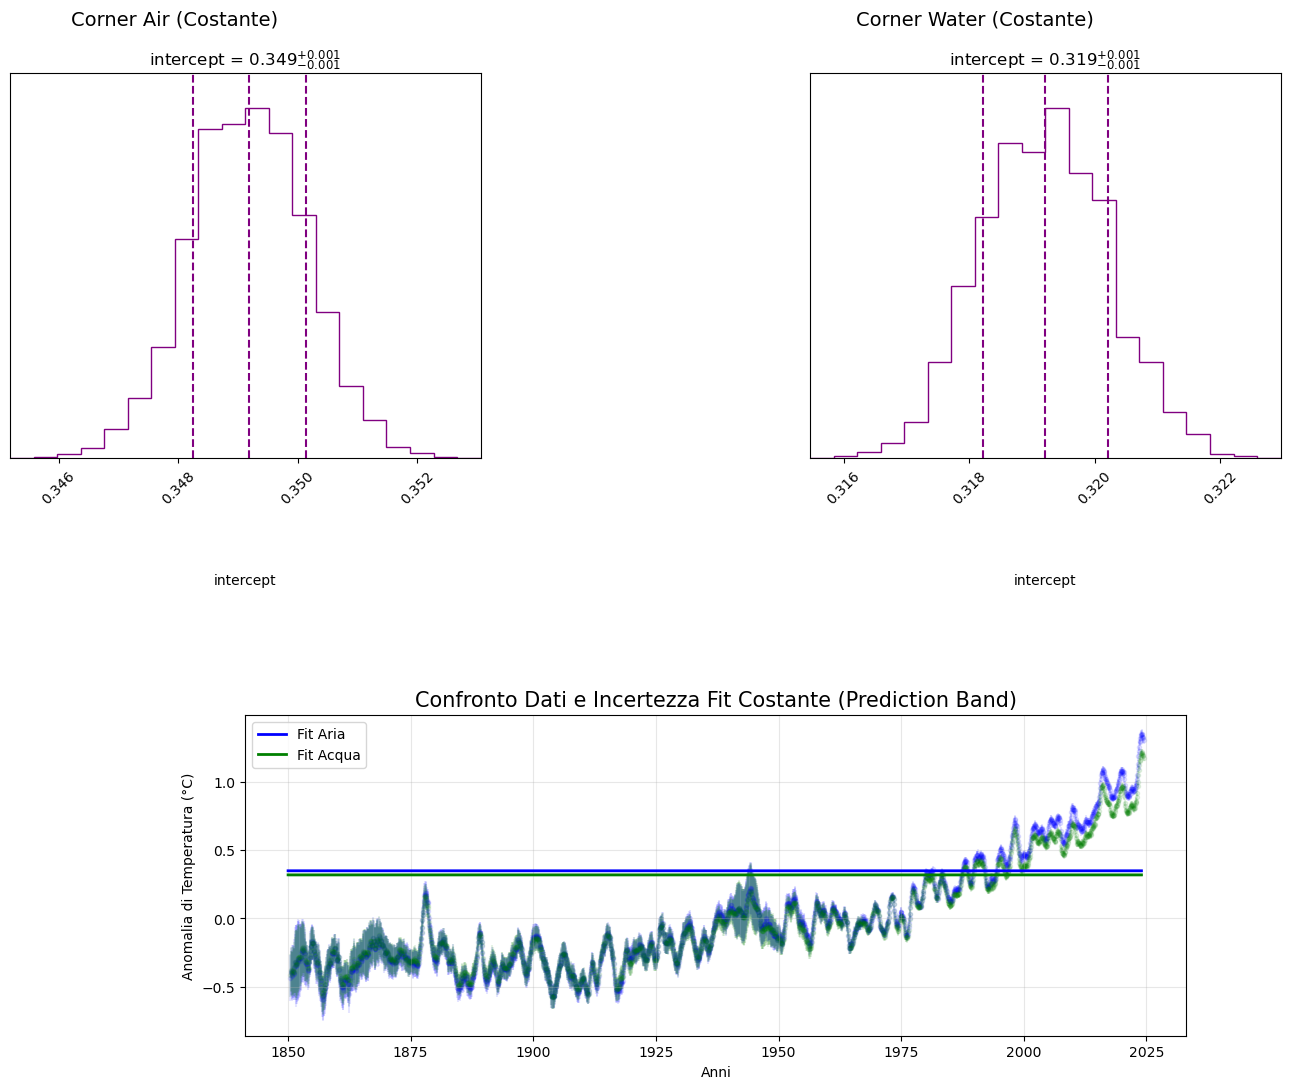

In [23]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.3f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.3f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_start = 1850
t_end = 2024
t_grid_plot = np.linspace(t_start, t_end, 2088)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid_plot)

    for val in samples:
        band.add(np.full_like(t_grid_plot, val))
    
    ax.errorbar(data['time_years'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

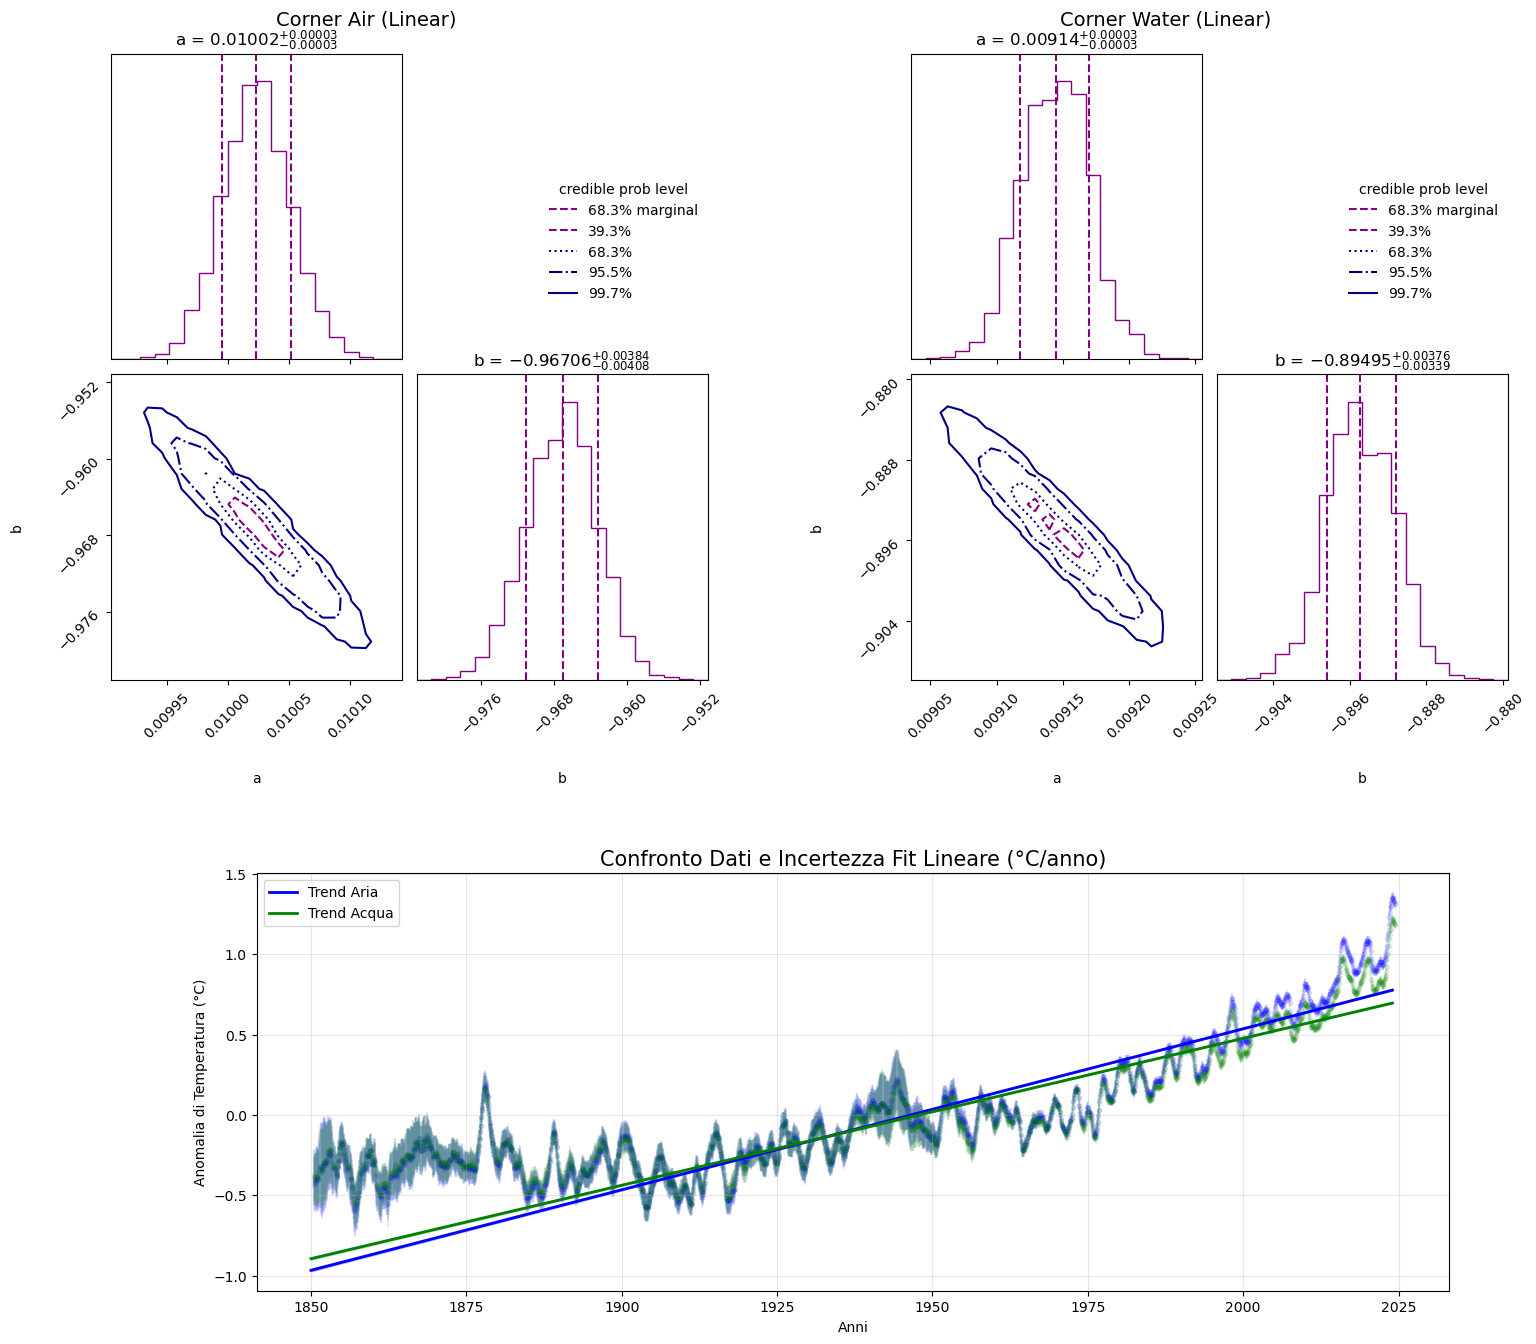

In [24]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.5f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.5f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_start = 1850
t_end = 2024
t_grid_plot = np.linspace(t_start, t_end, 2088)
t_grid_calc = t_grid_plot - t_start


def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid_plot)

    for a, b in samples:
        band.add(a * t_grid_calc + b)
        
    ax.errorbar(data['time_years'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

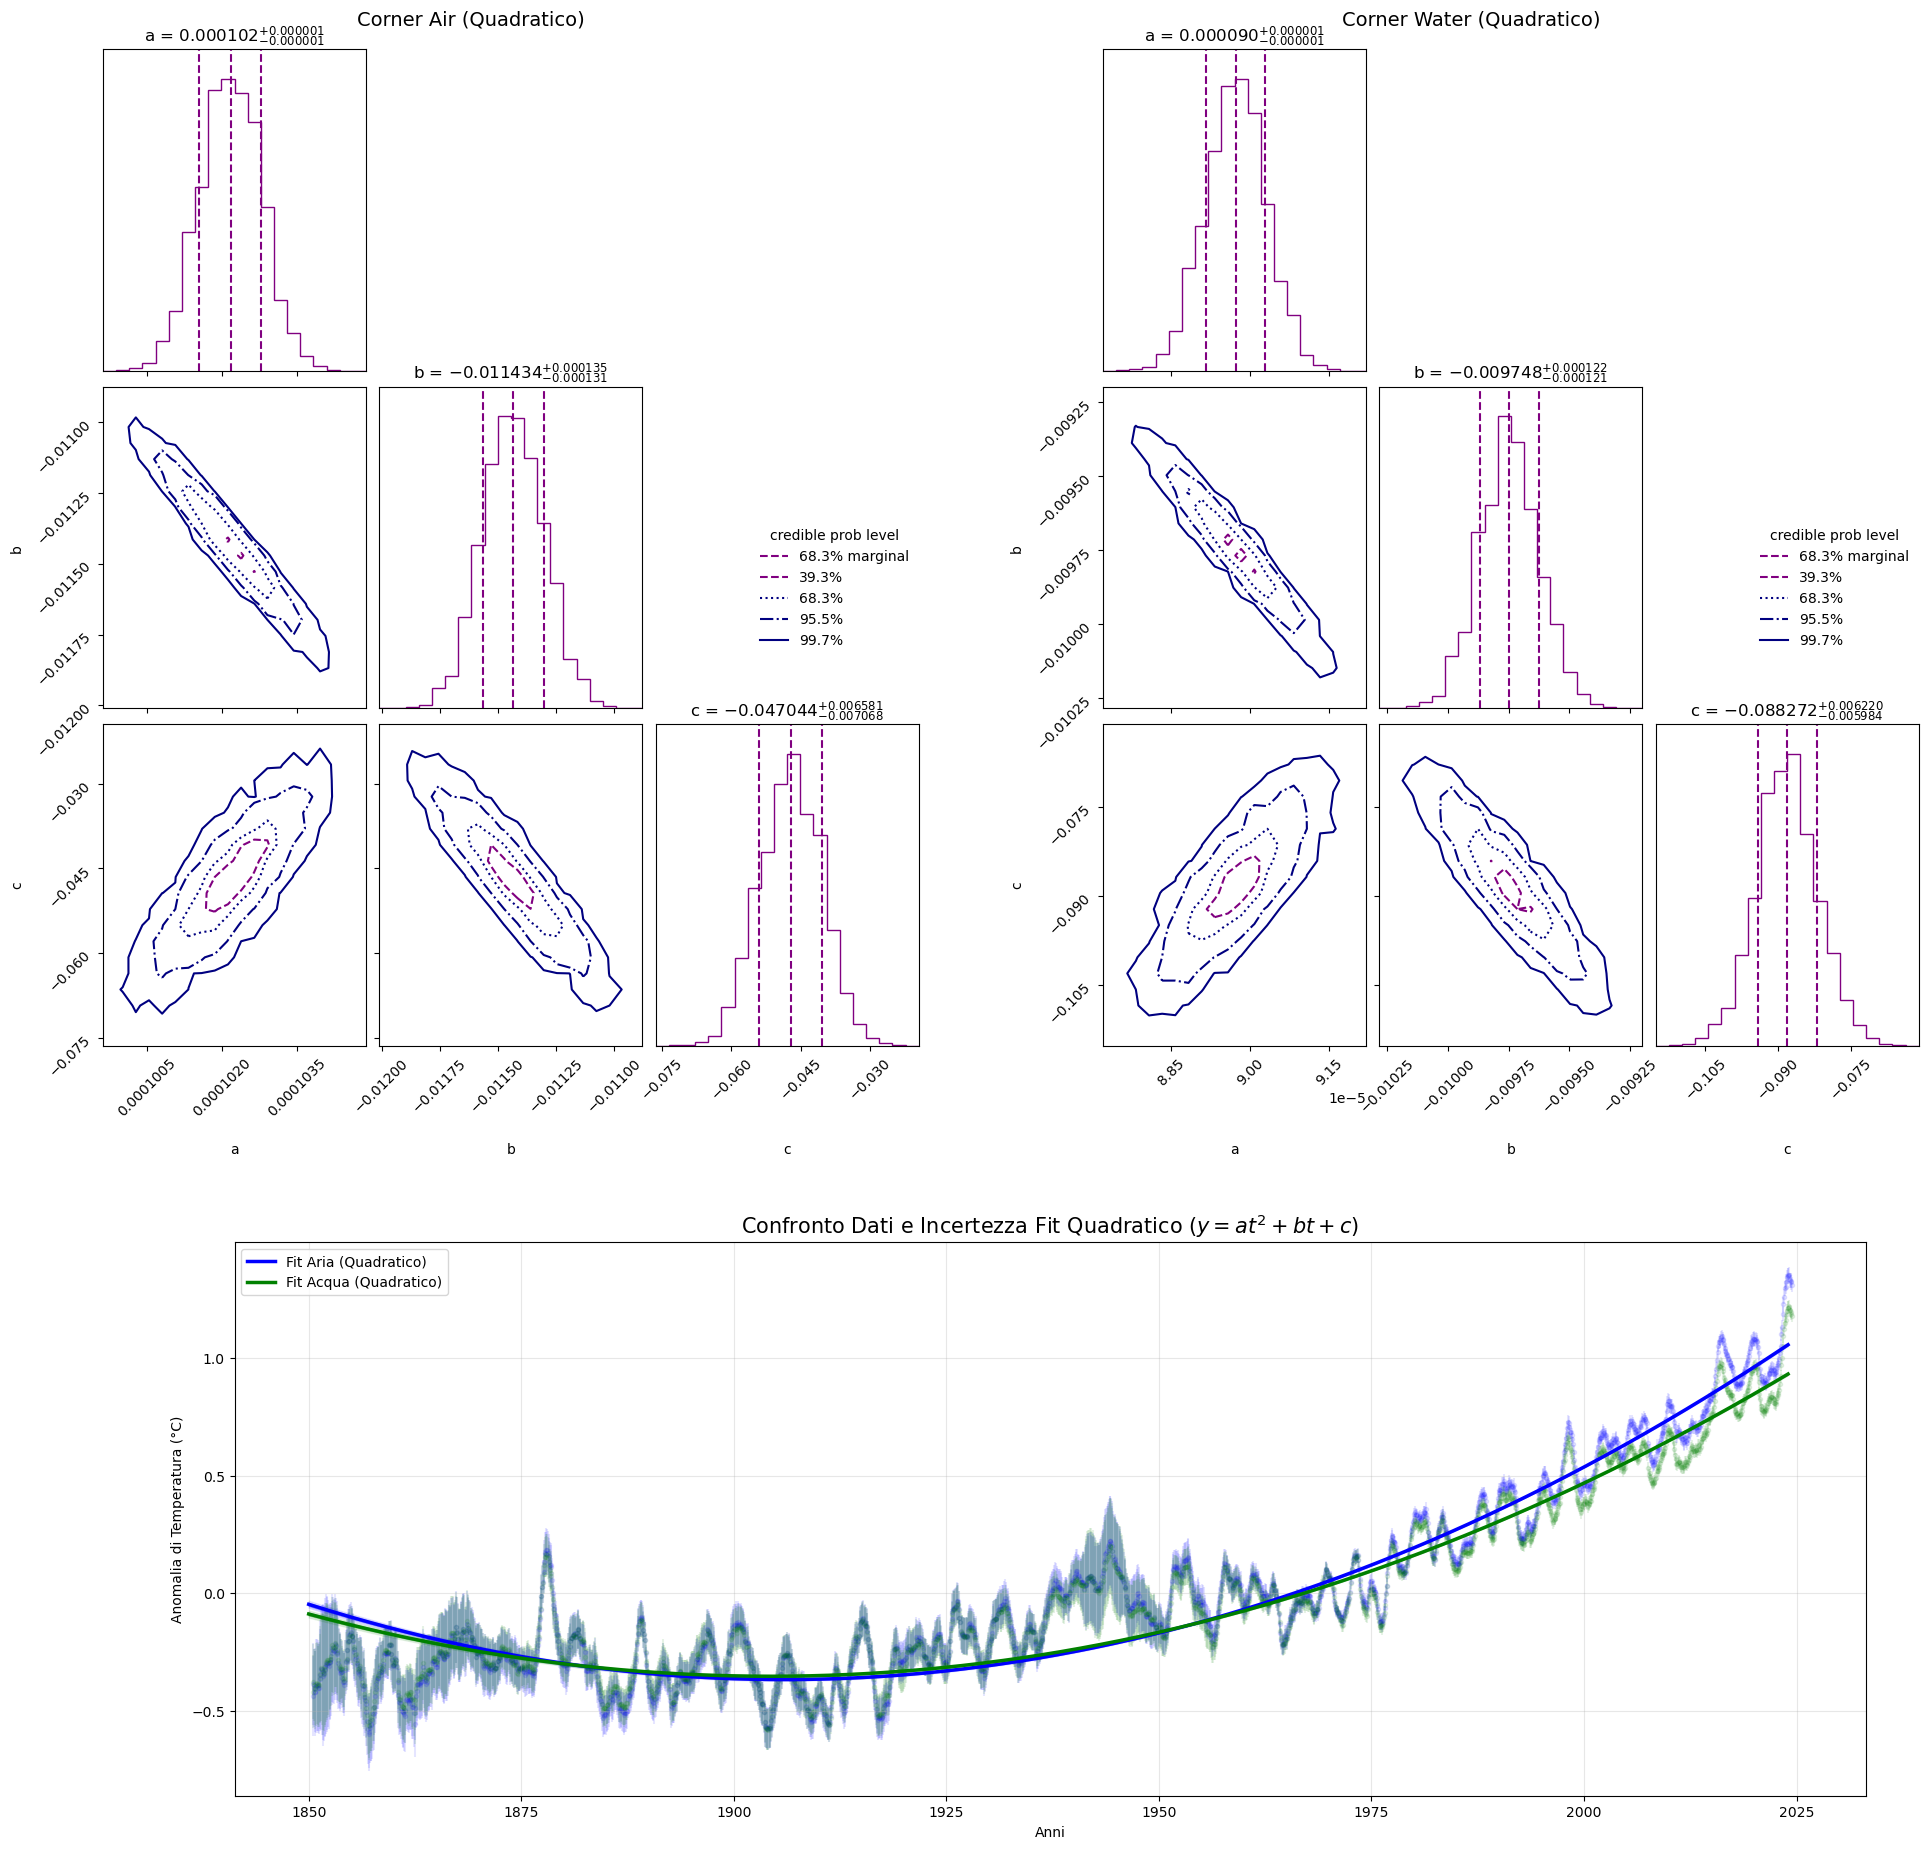

In [20]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_start = 1850
t_end = 2024
t_grid_plot = np.linspace(t_start, t_end, 2088)
t_grid_calc = t_grid_plot - t_start


def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid_plot)
    
    for a, b, c in samples:
        band.add(a * t_grid_calc**2 + b * t_grid_calc + c)
    
    ax.errorbar(data['time_years'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

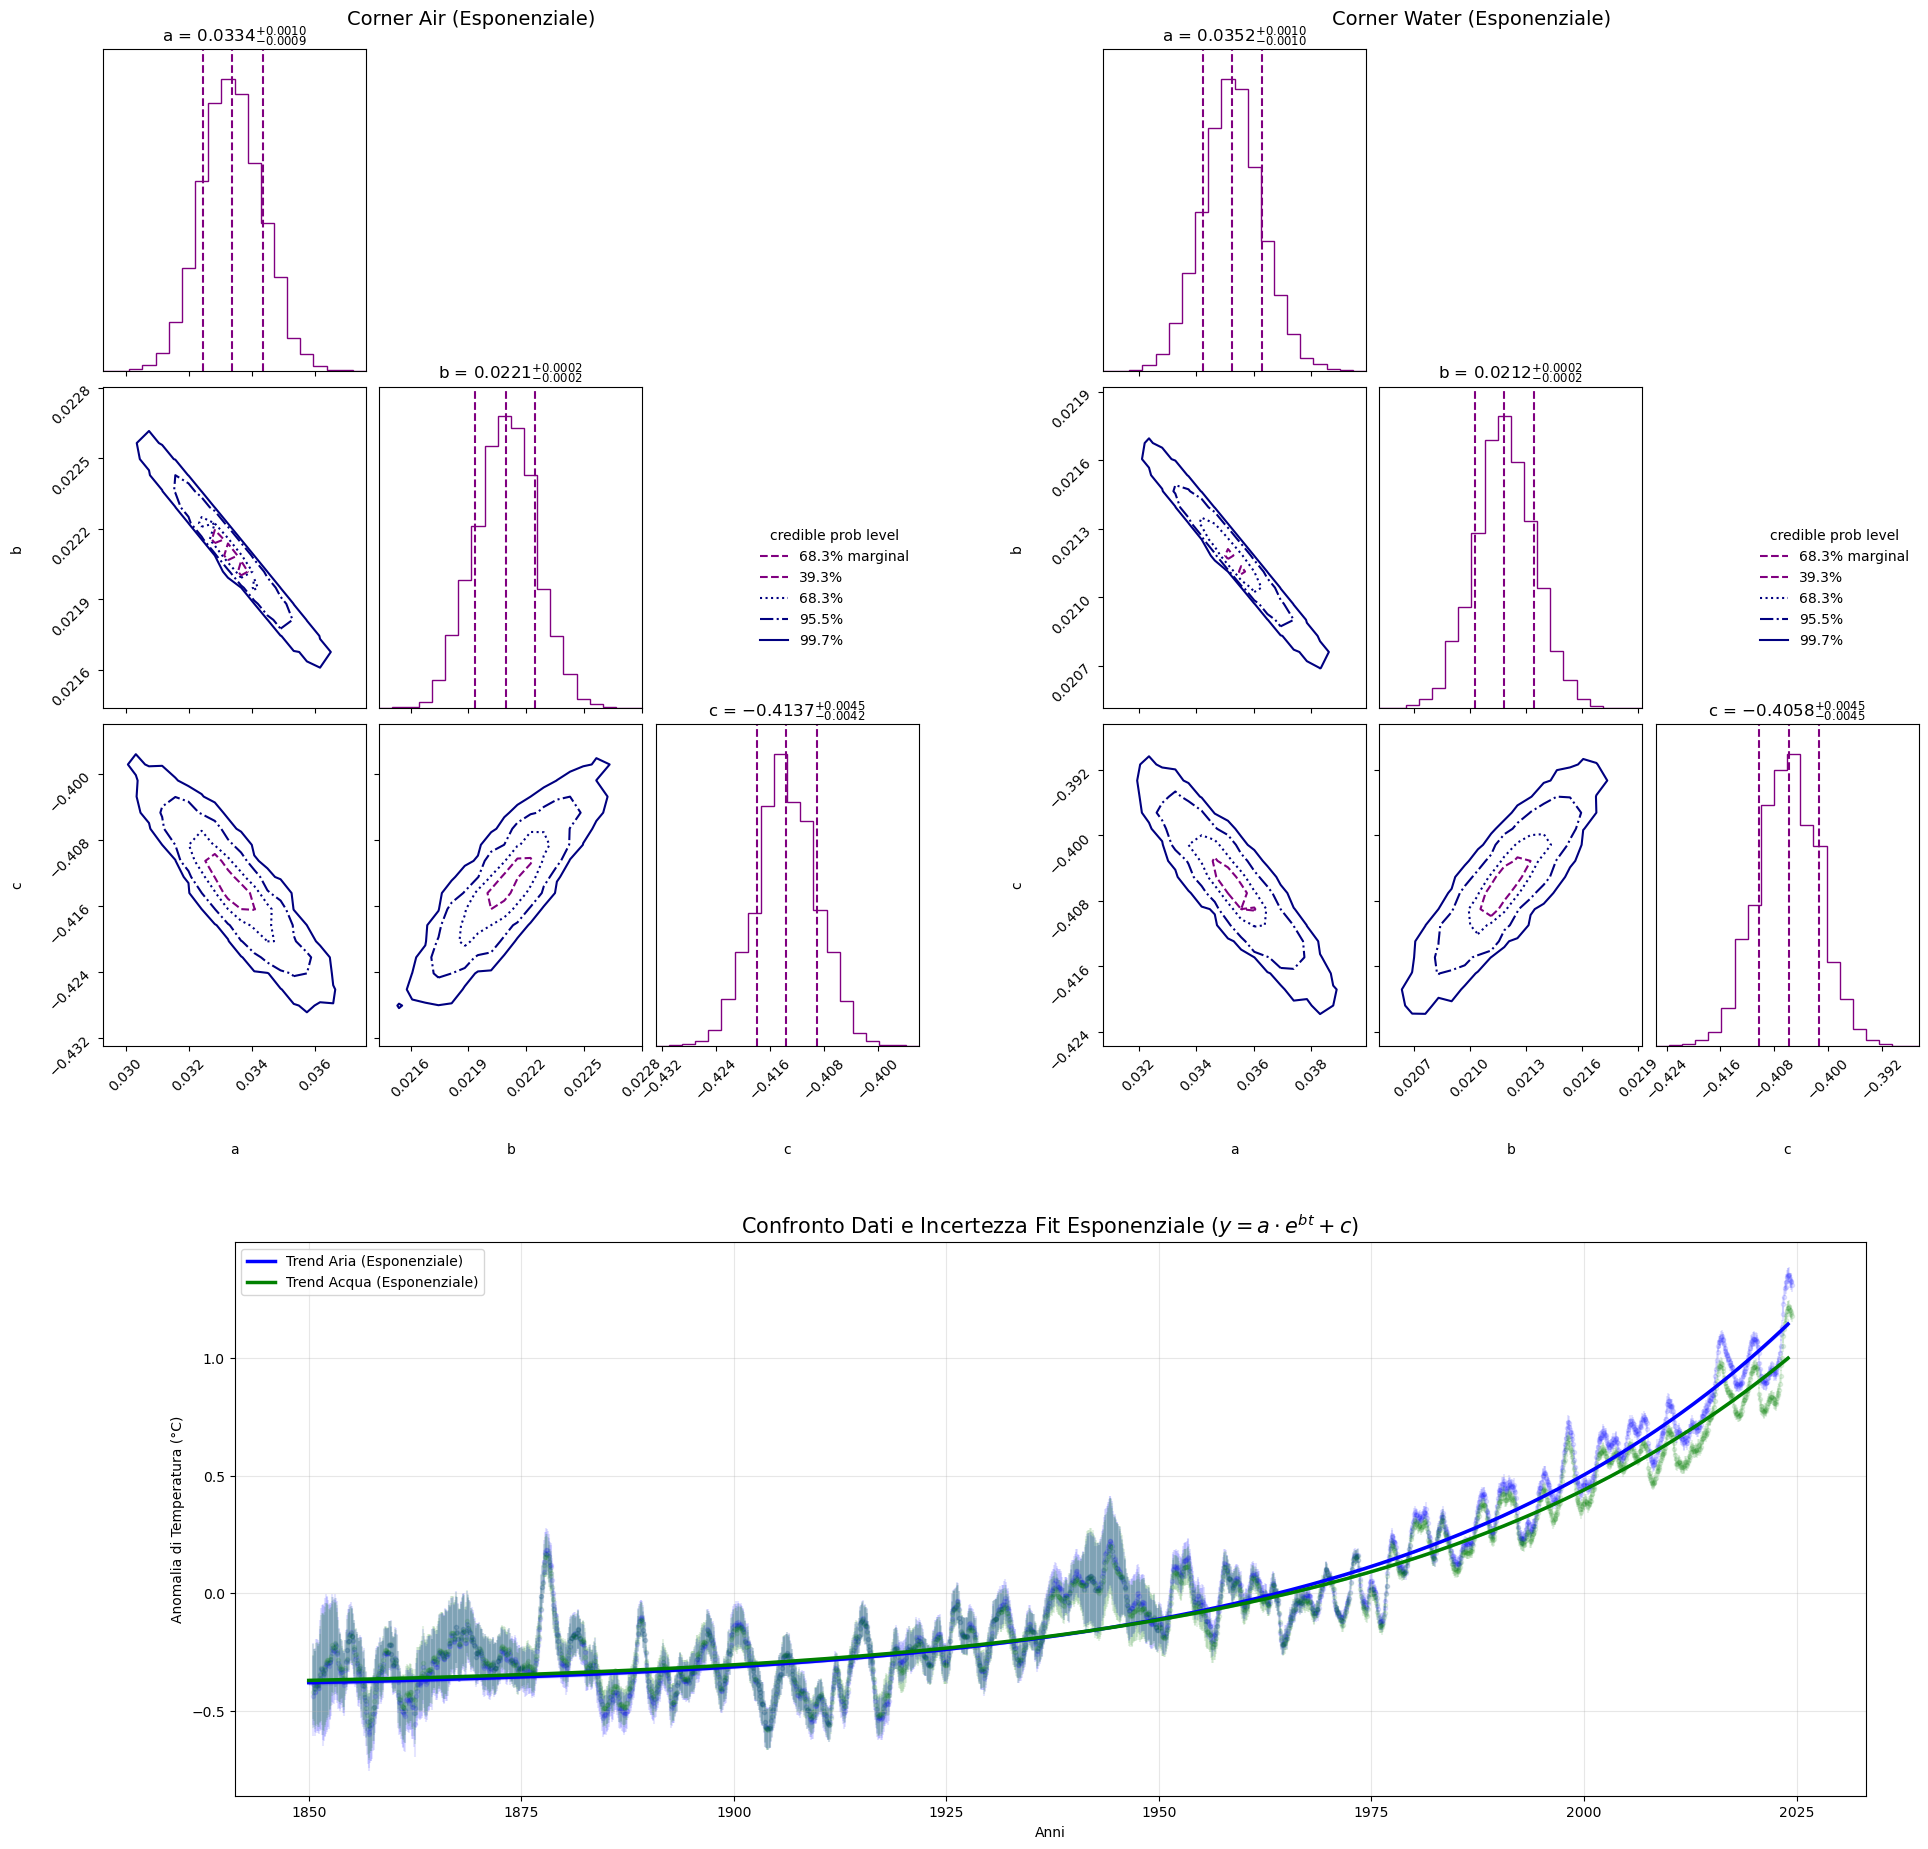

In [25]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_start = 1850
t_end = 2024
t_grid_plot = np.linspace(t_start, t_end, 2088)
t_grid_calc = t_grid_plot - t_start


def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid_plot)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid_calc) + c)
    
    ax.errorbar(data['time_years'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

### Confronto tra i vari modelli usando l'evidenza

In [26]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")


--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81424.61 |         0.00
linear          |    -20205.55 |     61219.06
quadratic       |     -2172.44 |     79252.18
exponential     |     -1703.07 |     79721.54

--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): WATER ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -74220.17 |         0.00
linear          |    -18251.09 |     55969.08
quadratic       |     -1983.15 |     72237.02
exponential     |     -1709.74 |     72510.43

--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81424.61 |    -61219.06
linear          |    -20205.55 |         0.00
quadratic       |     -2172.44 |     18033.12
exponential     |     -1703.07 |  